# FAM Churn Prediction — v3 (production build)

**What this notebook does differently from v2, and why the score moves**

| Lever | v2 | v3 | Effect |
|---|---|---|---|
| Training rows | 1 snapshot (cutoff May 8) → 1 row/user | **Rolling snapshots** (a cutoff every day) → ~10 rows/user | ~10× more labelled examples, far more stable model |
| Features | 14 transaction features over one 20-day window | **~55 features**: 3/7/14-day windows, recency, purchase-rhythm gaps, "overdue vs my own pattern", momentum, history baseline | Biggest single source of lift |
| Leaky columns | 4 engagement columns kept (snapshot as of May 19) | **Excluded by default** (toggle + ablation) — with many cutoffs they leak the label window into *every* snapshot | Honest metric |
| Evaluation | random row split | **User-disjoint** splits, test on the **latest cutoff only**, headline metric on **eligible** users, bootstrap CI | Number you can trust |
| Models | LightGBM / XGBoost (15 trials) + CatBoost | Optuna-tuned LightGBM + XGBoost + CatBoost → **weighted blend** → **isotonic calibration** | Higher PR-AUC, real probabilities |
| Threshold | picked on the test set | picked on **validation**, reported on test; compared to the closed-form optimum | No optimism |
| Code reuse | functions copy-pasted | **One module** (`churn_features.py`) imported by training *and* scoring + automated **leakage tests** | No train/serve skew |

> **On "maximum score".** I can't promise a number — it depends on your data. What this notebook does is remove every source of *fake* score (leakage, already-dormant users, tuning on test) and add every source of *real* score. If a number looks too good, the ablation and leakage tests in Stages 4 and 9 are there to tell you why.

## Stage 1 — Problem design: snapshots

A **snapshot** is "stand on a cutoff day D, look **back** to build features, look **forward** to build the label":

```
                    cutoff D
   ◄──── 14-day look-back ────┤├──── 7-day horizon ────►
   features (X)               │     label (y): churn = 0 transactions in (D, D+7]
```

We repeat this for **every possible cutoff** in the data and stack the results — one row per *(user, cutoff)*.

```
data:   Apr19 ─────────────────────────────────────────────── May19
cutoff May 2   [look-back Apr19..May2][label May3..May9]
cutoff May 3      [look-back Apr20..May3][label May4..May10]
   ...
cutoff May 12                        [look-back Apr29..May12][label May13..May19]
```

- Same raw rows appear as *features* in one snapshot and as *label* in another — nothing is wasted.
- **Eligible** user = at least one transaction in the look-back window (i.e. currently active). Users already silent for 14+ days "churn" trivially; scoring them inflates metrics but gives the retention team nothing to act on. We train on everyone, but the **headline metric uses eligible users only** (both are reported).
- `HORIZON` (7 days) is a business choice: how far ahead the retention team needs warning. It is a config value, not a law.

In [1]:
# pip install -U pandas numpy scikit-learn lightgbm xgboost catboost optuna shap matplotlib joblib
import os, sys, json, time, warnings, itertools, importlib
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80); pd.set_option('display.width', 220)

RANDOM_STATE = 42
USERS_PATH = r'data\raw\fam_users.csv'
TXN_PATH   = r'data\raw\fam_transactions.csv'

ARTIFACT_DIR = 'churn_artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

# ---- design choices -----------------------------------------------------------------------
HORIZON = 7                  # days ahead we predict silence for
CUTOFF_STEP = 3              # a snapshot every N days
USE_ENGAGEMENT_COLS = False  # app_opens_per_week etc.: unknown window -> leak risk (see Stage 2)
N_TRIALS = 40                # Optuna trials per model (raise for the final run)
MAX_TREES = 3000             # upper bound; early stopping picks the real number
if os.environ.get('CHURN_FAST') == '1':      # smoke-test mode only
    N_TRIALS, MAX_TREES = 3, 200

# ---- business assumptions (REPLACE with finance/marketing numbers) ------------------------
AVG_CUSTOMER_VALUE = 2000    # INR value of keeping a customer one more period
CAMPAIGN_COST      = 150     # INR per retention contact
CAMPAIGN_SAVE_RATE = 0.25    # share of targeted would-be churners the campaign actually saves

## Stage 2 — Load, audit, leakage decisions

In [2]:
t0 = time.time()
users = pd.read_csv(USERS_PATH, parse_dates=['registration_date'])
txns  = pd.read_csv(TXN_PATH, parse_dates=['transaction_date'])
txns  = txns.drop_duplicates('transaction_id')
print(f'users {users.shape} | txns {txns.shape} | loaded in {time.time()-t0:.1f}s')
display(users.head(3)); display(txns.head(3))

users (500000, 15) | txns (4045175, 9) | loaded in 13.5s


,user_id,registration_date,age_group,city,device_type,days_since_registration,app_opens_per_week,avg_session_duration,support_tickets,referrals_made,has_customized_card,has_set_savings_goal,has_used_offers,days_since_last_transaction,is_active
0,U000001,2025-04-11 15:21:09.617688,16-18,Mumbai,Android,38,11,5.3,3,0,1,0,1,0,1
1,U000002,2024-07-15 15:21:09.617688,31+,Hyderabad,Android,308,14,5.4,0,1,1,0,0,18,0
2,U000003,2024-05-31 15:21:09.617688,19-22,Chennai,Android,353,3,5.8,2,5,0,0,0,30,0


,transaction_id,user_id,transaction_date,amount,payment_method,transaction_type,merchant,status,failure_reason
0,TXN3223009,U000001,2025-05-07 15:21:09.617688,529.97,UPI,Travel,MakeMyTrip,Success,NaN
1,TXN6653676,U000001,2025-04-29 15:21:09.617688,359.74,UPI,Entertainment,BookMyShow,Success,NaN
2,TXN5673139,U000001,2025-04-24 15:21:09.617688,234.00,UPI,Bills,DTH,Success,NaN


txn range       : 2025-04-19 15:21:09.617688 -> 2025-05-19 15:21:09.617688
dup user_ids    : 0
txns of unknown users: 0
non-positive amounts : 0
status mix      : {'Success': 0.96, 'Failed': 0.04}
users with >=1 txn: 452,017 of 500,000
is_active      0       1
dslt<=14                
False      95522       0
True           0  404478
gap between active days, quantiles: {0.5: 2.0, 0.75: 4.0, 0.9: 7.0, 0.95: 9.0}


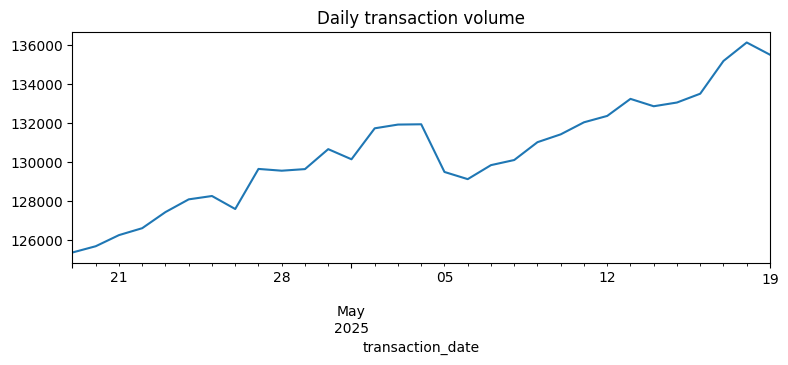

In [3]:
print('txn range       :', txns['transaction_date'].min(), '->', txns['transaction_date'].max())
print('dup user_ids    :', users['user_id'].duplicated().sum())
print('txns of unknown users:', (~txns['user_id'].isin(users['user_id'])).sum())
print('non-positive amounts :', (txns['amount'] <= 0).sum())
print('status mix      :', txns['status'].value_counts(normalize=True).round(3).to_dict())
print(f"users with >=1 txn: {txns['user_id'].nunique():,} of {len(users):,}")

# 1) is_active is a restatement of days_since_last_transaction -> label-shaped, never a feature
print(pd.crosstab(users['days_since_last_transaction'] <= 14, users['is_active'], rownames=['dslt<=14'], colnames=['is_active']))

# 2) purchase rhythm: how long are normal silences? (sanity-check for HORIZON)
d = (txns.assign(day=txns['transaction_date'].dt.normalize())
         .drop_duplicates(['user_id', 'day']).sort_values(['user_id', 'day']))
gaps = d.groupby('user_id')['day'].diff().dt.days.dropna()
print('gap between active days, quantiles:', gaps.quantile([.5, .75, .9, .95]).to_dict())

daily = txns.set_index('transaction_date').resample('D').size()
daily.plot(figsize=(9, 3), title='Daily transaction volume'); plt.show()

**Leakage decisions (all enforced in code, not just documented):**

| Column(s) | Decision | Reason |
|---|---|---|
| `is_active`, `days_since_last_transaction`, `days_since_registration` | **Dropped** | Snapshot-relative to May 19 — they encode the label window. Recomputed per cutoff instead (`days_since_last_txn`, `tenure_days`). |
| `app_opens_per_week`, `avg_session_duration`, `support_tickets`, `referrals_made` | **Off by default** (`USE_ENGAGEMENT_COLS`) | Pre-aggregated, unknown window, one value per user. In a multi-snapshot build the same number is attached to *every* cutoff, so for early cutoffs it contains future behaviour. Stage 9 has an optional ablation; if they "help a lot" that is a red flag, not a win. Ask the data team for timestamped event logs. |
| Users registered after the cutoff | **Dropped for that snapshot** | They didn't exist yet — their tenure would be negative. |

## Stage 3 — Feature module (single source of truth)

Written to disk and imported — the scoring service imports the **same file**, so feature logic cannot drift between training and serving.

In [4]:
%%writefile churn_artifacts/churn_features.py
"""
churn_features.py -- SINGLE SOURCE OF TRUTH for feature + label logic.
Imported by the training notebook AND by churn_scoring.py, so train/serve skew is impossible
by construction.

Concept: a *snapshot* = (cutoff day D).
    features  <- transactions with day <= D          (never anything after D)
    label     <- transactions with D < day <= D + horizon
One row per (user, cutoff). Many cutoffs are stacked to form the training table.
"""
import numpy as np
import pandas as pd

WINDOWS = (3, 7, 14)              # look-back windows in days (day 0 = cutoff day)
LOOKBACK = max(WINDOWS)
FAILED = 'Failed'

STATIC_CAT = ['age_group', 'city', 'device_type']
STATIC_NUM = ['has_customized_card', 'has_set_savings_goal', 'has_used_offers']
ENGAGEMENT = ['app_opens_per_week', 'avg_session_duration', 'support_tickets', 'referrals_made']
CAT_FEATURES = STATIC_CAT + ['top_txn_type']
META_COLS = ['user_id', 'cutoff', 'churn', 'eligible']

FEATURE_GROUPS = {
    'user_static': STATIC_CAT + STATIC_NUM + ['tenure_days', 'is_new_user'],
    'recency': ['days_since_last_txn', 'days_since_last_ok_txn', 'active_span_days'],
    'windowed_activity': [f'{p}_{w}d' for p in ('cnt', 'amt', 'fail', 'active_days', 'merchants')
                          for w in WINDOWS],
    'rhythm_gaps': ['gap_mean', 'gap_max', 'gap_std', 'overdue_ratio', 'overdue_vs_max'],
    'momentum': ['share_last3', 'cnt_7d_vs_prev7', 'amt_7d_vs_prev7', 'velocity_ratio', 'rate_ratio_7d'],
    'history_baseline': ['hist_cnt', 'hist_active_days', 'hist_active_share', 'hist_rate'],
    'mix_quality': ['amt_mean', 'amt_std', 'amt_max', 'n_merchants', 'n_pay_methods', 'n_txn_types',
                    'top_merchant_share', 'top_txn_type', 'top_txn_type_share', 'weekend_share',
                    'failure_rate'],
    'engagement_cols': ENGAGEMENT,
}


def prep_txns(txns):
    """One-off vectorised prep (call once, reuse for every cutoff)."""
    t = txns.copy()
    t['day'] = t['transaction_date'].dt.normalize()
    t['is_failed'] = (t['status'] == FAILED).astype('int8')
    t['ok_amount'] = t['amount'].where(t['is_failed'] == 0, 0.0)
    return t


def snapshot_features(t, users, cutoff, data_start, use_engagement=False):
    """Feature table for ONE cutoff day. `t` must come from prep_txns().
    Uses only rows with day <= cutoff. Returns one row per eligible-registered user."""
    cutoff = pd.Timestamp(cutoff).normalize()
    data_start = pd.Timestamp(data_start).normalize()
    L = f'{LOOKBACK}d'

    hist = t[t['day'] <= cutoff]                                   # everything known at cutoff
    win = hist[hist['day'] > cutoff - pd.Timedelta(days=LOOKBACK)].copy()
    win['days_ago'] = (cutoff - win['day']).dt.days                # 0 = cutoff day

    # ---- windowed activity (3d / 7d / 14d) ---------------------------------------------
    f = pd.DataFrame(index=pd.Index(win['user_id'].unique(), name='user_id'))
    for w in WINDOWS:
        g = win[win['days_ago'] < w].groupby('user_id')
        f[f'cnt_{w}d'] = g.size()
        f[f'amt_{w}d'] = g['ok_amount'].sum()                      # successful money only
        f[f'fail_{w}d'] = g['is_failed'].sum()
        f[f'active_days_{w}d'] = g['day'].nunique()
        f[f'merchants_{w}d'] = g['merchant'].nunique()
    zero_cols = list(f.columns)
    f[zero_cols] = f[zero_cols].fillna(0)

    # ---- lookback-wide amount / diversity / span ----------------------------------------
    g = win.groupby('user_id')
    f['amt_mean'] = g['amount'].mean()
    f['amt_std'] = g['amount'].std()
    f['amt_max'] = g['amount'].max()
    f['n_merchants'] = g['merchant'].nunique()
    f['n_pay_methods'] = g['payment_method'].nunique()
    f['n_txn_types'] = g['transaction_type'].nunique()
    f['active_span_days'] = (g['day'].max() - g['day'].min()).dt.days
    f['failure_rate'] = f[f'fail_{L}'] / f[f'cnt_{L}']
    f['weekend_share'] = win.assign(_w=(win['day'].dt.dayofweek >= 5)).groupby('user_id')['_w'].mean()

    # ---- concentration -------------------------------------------------------------------
    mc = win.groupby(['user_id', 'merchant']).size().groupby(level='user_id').max()
    f['top_merchant_share'] = mc / f[f'cnt_{L}']
    tc = (win.groupby(['user_id', 'transaction_type']).size().rename('n').reset_index()
          .sort_values(['user_id', 'n', 'transaction_type'], ascending=[True, False, True])   # deterministic ties
          .drop_duplicates('user_id').set_index('user_id'))
    f['top_txn_type'] = tc['transaction_type']
    f['top_txn_type_share'] = tc['n'] / f[f'cnt_{L}']

    # ---- purchase rhythm: gaps between ACTIVE days, and "overdue" vs own pattern -----------
    days = win[['user_id', 'day']].drop_duplicates().sort_values(['user_id', 'day'])
    days['gap'] = days.groupby('user_id')['day'].diff().dt.days
    gg = days.groupby('user_id')['gap']
    f['gap_mean'], f['gap_max'], f['gap_std'] = gg.mean(), gg.max(), gg.std()

    # ---- full-history recency + baseline (still only day <= cutoff) ------------------------
    h = hist.groupby('user_id').agg(hist_cnt=('amount', 'size'), hist_active_days=('day', 'nunique'),
                                    hist_last=('day', 'max'))
    h['hist_last_ok'] = hist[hist['is_failed'] == 0].groupby('user_id')['day'].max()
    observed_days = (cutoff - data_start).days + 1
    h['days_since_last_txn'] = (cutoff - h['hist_last']).dt.days
    h['days_since_last_ok_txn'] = (cutoff - h['hist_last_ok']).dt.days
    h['hist_active_share'] = h['hist_active_days'] / observed_days
    h['hist_rate'] = h['hist_cnt'] / observed_days
    h = h.drop(columns=['hist_last', 'hist_last_ok'])

    # ---- users: registered on/before cutoff only ------------------------------------------
    u = users.copy()
    u['_reg'] = u['registration_date'].dt.normalize()
    u = u[u['_reg'] <= cutoff]
    u['tenure_days'] = (cutoff - u['_reg']).dt.days
    u['is_new_user'] = (u['tenure_days'] <= LOOKBACK).astype('int8')
    keep = ['user_id'] + STATIC_CAT + STATIC_NUM + ['tenure_days', 'is_new_user']
    if use_engagement:
        keep += ENGAGEMENT
    table = u[keep].set_index('user_id').join(f).join(h)

    fill0 = zero_cols + ['n_merchants', 'n_pay_methods', 'n_txn_types', 'hist_cnt', 'hist_active_days',
                         'hist_active_share', 'hist_rate']
    table[fill0] = table[fill0].fillna(0)
    table['top_txn_type'] = table['top_txn_type'].fillna('None')

    # ---- momentum / ratios (after zero-fill so dormant users are well defined) -------------
    table['share_last3'] = table['cnt_3d'] / table[f'cnt_{L}'].replace(0, np.nan)
    table['cnt_7d_vs_prev7'] = table['cnt_7d'] - (table[f'cnt_{L}'] - table['cnt_7d'])
    table['amt_7d_vs_prev7'] = table['amt_7d'] - (table[f'amt_{L}'] - table['amt_7d'])
    table['velocity_ratio'] = (table['cnt_3d'] / 3) / (table[f'cnt_{L}'] / LOOKBACK + 1e-6)
    table['rate_ratio_7d'] = (table['cnt_7d'] / 7) / (table['hist_rate'] + 1e-6)
    table['overdue_ratio'] = table['days_since_last_txn'] / (table['gap_mean'] + 1.0)
    table['overdue_vs_max'] = table['days_since_last_txn'] - table['gap_max']

    table = table.replace([np.inf, -np.inf], np.nan).reset_index()
    table['cutoff'] = cutoff
    table['eligible'] = (table[f'cnt_{L}'] > 0).astype('int8')    # active in look-back => meaningful to score
    return table


def make_label(t, user_ids, cutoff, horizon):
    """churn=1 if the user has ZERO transactions in (cutoff, cutoff+horizon]. Label-only; never a feature."""
    cutoff = pd.Timestamp(cutoff).normalize()
    fut = t[(t['day'] > cutoff) & (t['day'] <= cutoff + pd.Timedelta(days=horizon))]
    active = set(fut['user_id'].unique())
    return (~pd.Series(user_ids).isin(active)).astype('int8').values


def make_cutoffs(txns, horizon, step=1):
    """Every cutoff with a full look-back behind it and a full label horizon ahead of it."""
    d0, d1 = txns['transaction_date'].min().normalize(), txns['transaction_date'].max().normalize()
    first = d0 + pd.Timedelta(days=LOOKBACK - 1)
    last = d1 - pd.Timedelta(days=horizon)
    return list(pd.date_range(first, last, freq=f'{step}D'))


def build_training_table(txns, users, cutoffs, horizon, use_engagement=False):
    t = prep_txns(txns)
    data_start = txns['transaction_date'].min()
    parts = []
    for c in cutoffs:
        tab = snapshot_features(t, users, c, data_start, use_engagement)
        tab['churn'] = make_label(t, tab['user_id'].values, c, horizon)
        parts.append(tab)
    return pd.concat(parts, ignore_index=True)


def build_live_table(txns, users, cutoff, data_start, use_engagement=False):
    """Scoring mode: same features, NO label (the future does not exist yet)."""
    return snapshot_features(prep_txns(txns), users, cutoff, data_start, use_engagement)


def feature_columns(table):
    return [c for c in table.columns if c not in META_COLS]


def to_model_frame(df, features, cat_features, categories, as_string=False):
    """Model-ready frame. Categoricals get a FIXED category list learned at training time, so
    scoring can never shift category codes. as_string=True gives plain strings (CatBoost / sklearn OHE)."""
    X = df[features].copy()
    for c in cat_features:
        s = X[c].astype(str)
        X[c] = s.astype(object) if as_string else pd.Categorical(s, categories=categories[c])
    return X

Overwriting churn_artifacts/churn_features.py


In [5]:
sys.path.insert(0, ARTIFACT_DIR)
import churn_features as cf
importlib.reload(cf)

# ---- automated leakage tests: poison every post-cutoff row; features must not change --------
def assert_no_future_leak(cutoff):
    ds = txns['transaction_date'].min()
    base = cf.snapshot_features(cf.prep_txns(txns), users, cutoff, ds)
    bad = txns.copy()
    future = bad['transaction_date'].dt.normalize() > pd.Timestamp(cutoff)
    bad.loc[future, 'amount'] = 9e9
    bad.loc[future, 'status'] = 'Failed'
    bad.loc[future, 'merchant'] = 'POISON'
    bad.loc[future, 'user_id'] = bad.loc[future, 'user_id'].sample(frac=1, random_state=0).values
    poisoned = cf.snapshot_features(cf.prep_txns(bad), users, cutoff, ds)
    key = lambda d: d.sort_values('user_id').reset_index(drop=True)
    pd.testing.assert_frame_equal(key(base), key(poisoned))

_cuts = cf.make_cutoffs(txns, HORIZON, CUTOFF_STEP)
for c in [_cuts[0], _cuts[len(_cuts) // 2], _cuts[-1]]:
    assert_no_future_leak(c)
print(f'PASS: features at {len(_cuts)} cutoffs are unaffected by any post-cutoff transaction (3 spot-checked)')

# ---- registry test: every produced feature belongs to a documented group ---------------------
_tab = cf.snapshot_features(cf.prep_txns(txns), users, _cuts[-1], txns['transaction_date'].min(), USE_ENGAGEMENT_COLS)
_known = set(sum(cf.FEATURE_GROUPS.values(), []))
assert set(cf.feature_columns(_tab)) <= _known, set(cf.feature_columns(_tab)) - _known
print('PASS: feature registry covers all', len(cf.feature_columns(_tab)), 'features')

PASS: features at 4 cutoffs are unaffected by any post-cutoff transaction (3 spot-checked)
PASS: feature registry covers all 51 features


### Feature catalogue (what each feature is and why it should predict churn)

| Group | Features | Logic | Why it helps |
|---|---|---|---|
| **recency** | `days_since_last_txn`, `days_since_last_ok_txn`, `active_span_days` | cutoff − last transaction (from *all* history, not just the look-back); `NaN` if never transacted | Strongest single signal; the `ok` version ignores failed payments |
| **windowed activity** | `cnt_/amt_/fail_/active_days_/merchants_` × `3d,7d,14d` | counts / successful ₹ / failures / distinct active days / distinct merchants per window | Multi-scale view — a drop in the last 3 days is invisible in a 20-day total |
| **rhythm & overdue** | `gap_mean/max/std`, `overdue_ratio`, `overdue_vs_max` | gaps between active days; `overdue_ratio = days_since_last / (gap_mean+1)`; `overdue_vs_max = days_since_last − gap_max` | A weekly shopper silent for 9 days is alarming; a monthly one is not. Compares each user with *their own* pattern |
| **momentum** | `share_last3`, `cnt_7d_vs_prev7`, `amt_7d_vs_prev7`, `velocity_ratio`, `rate_ratio_7d` | last-3-day share, this week vs previous week, recent rate vs own history rate | Direction of travel, not just level |
| **history baseline** | `hist_cnt`, `hist_active_days`, `hist_active_share`, `hist_rate` | everything up to the cutoff since data start | Separates "always light" from "recently dropped" |
| **mix & quality** | `amt_mean/std/max`, `n_*`, `top_merchant_share`, `top_txn_type(_share)`, `weekend_share`, `failure_rate` | spend level, variety, concentration, failed-payment rate | Attachment and friction |
| **user static** | `age_group`, `city`, `device_type`, `has_*`, `tenure_days`, `is_new_user` | `tenure_days` is computed **at the cutoff** | Baseline propensity |

Missing values are kept as `NaN` where "no data" is itself informative (gap features for single-transaction users); counts are 0-filled. Tree models handle `NaN` natively.

## Stage 4 — See the transformation on a tiny example

Three toy users run through the **real** `churn_features` functions, so each table below is exactly what happens to your data, just small enough to read.

In [6]:
demo_users = pd.DataFrame({
    'user_id': ['A', 'B', 'C'],
    'registration_date': pd.to_datetime(['2024-11-10', '2025-01-03', '2025-03-15']),
    'age_group': ['25-34', '35-44', '18-24'], 'city': ['Patna', 'Gaya', 'Delhi'],
    'device_type': ['android', 'ios', 'android'],
    'has_customized_card': [1, 0, 0], 'has_set_savings_goal': [1, 1, 0], 'has_used_offers': [1, 0, 0]})
demo_txns = pd.DataFrame([
    ('T1', 'A', '2025-04-25 10:00', 200, 'Zomato', 'UPI',  'Food',     'Success'),
    ('T2', 'A', '2025-05-02 13:00', 450, 'Amazon', 'Card', 'Shopping', 'Failed'),
    ('T3', 'A', '2025-05-06 09:00', 150, 'Zomato', 'UPI',  'Food',     'Success'),
    ('T4', 'A', '2025-05-07 20:00', 300, 'Zomato', 'UPI',  'Food',     'Success'),
    ('T5', 'A', '2025-05-12 11:00', 250, 'Uber',   'UPI',  'Travel',   'Success'),
    ('T6', 'A', '2025-05-19 18:00', 100, 'Zomato', 'UPI',  'Food',     'Success'),
    ('T7', 'B', '2025-04-20 12:00', 900, 'Uber',   'UPI',  'Travel',   'Success'),
    ('T8', 'B', '2025-04-28 15:00', 400, 'Uber',   'UPI',  'Travel',   'Success'),
    ('T9', 'B', '2025-05-01 17:00', 350, 'Uber',   'UPI',  'Travel',   'Success'),
    ('T10','C', '2025-04-19 08:00', 120, 'Zomato', 'UPI',  'Food',     'Success')],
    columns=['transaction_id', 'user_id', 'transaction_date', 'amount', 'merchant', 'payment_method',
             'transaction_type', 'status'])
demo_txns['transaction_date'] = pd.to_datetime(demo_txns['transaction_date'])
D, H = pd.Timestamp('2025-05-08'), 7
dt = cf.prep_txns(demo_txns)

print('STEP 0 | RAW transactions (many rows per user)'); display(demo_txns)

inwin = dt[(dt['day'] <= D) & (dt['day'] > D - pd.Timedelta(days=cf.LOOKBACK))]
print(f'STEP 1 | rows the FEATURES may see: {(D - pd.Timedelta(days=cf.LOOKBACK-1)).date()} .. {D.date()}  (cutoff {D.date()})')
display(inwin[['transaction_id', 'user_id', 'day', 'amount', 'status']])

labwin = dt[(dt['day'] > D) & (dt['day'] <= D + pd.Timedelta(days=H))]
print(f'STEP 2 | rows the LABEL may see: {(D + pd.Timedelta(days=1)).date()} .. {(D + pd.Timedelta(days=H)).date()}  (never used as features)')
display(labwin[['transaction_id', 'user_id', 'day', 'amount', 'status']])

feat = cf.snapshot_features(dt, demo_users, D, demo_txns['transaction_date'].min())
feat['churn'] = cf.make_label(dt, feat['user_id'].values, D, H)
print('STEP 3 | ONE ROW PER USER (windows collapsed into features) + label')
display(feat[['user_id', 'cnt_3d', 'cnt_7d', 'cnt_14d', 'amt_14d', 'days_since_last_txn', 'gap_mean',
              'overdue_ratio', 'velocity_ratio', 'failure_rate', 'top_txn_type', 'eligible', 'churn']].round(2))
print('   A: txns May 2/6/7 in look-back, one on May 12 in horizon -> churn 0')
print('   B: last txn May 1, nothing after -> churn 1 (eligible: active in look-back)')
print('   C: only txn Apr 19, outside look-back -> eligible 0 (already dormant), churn 1')

stacked = cf.build_training_table(demo_txns, demo_users, [D, pd.Timestamp('2025-05-12')], H)
print('STEP 4 | SNAPSHOTS STACKED: same users, two cutoffs -> two rows each')
display(stacked[['user_id', 'cutoff', 'cnt_7d', 'days_since_last_txn', 'eligible', 'churn']])

_f = cf.feature_columns(stacked); _c = [c for c in cf.CAT_FEATURES if c in _f]
_cats = {c: sorted(stacked[c].astype(str).unique()) for c in _c}
print('STEP 5 | MODEL-READY matrix X (categoricals fixed, NaN kept) and target y')
display(cf.to_model_frame(stacked, _f, _c, _cats).head(3).T.head(18))
print('y =', stacked['churn'].tolist())

STEP 0 | RAW transactions (many rows per user)


,transaction_id,user_id,transaction_date,amount,merchant,payment_method,transaction_type,status
0,T1,A,2025-04-25 10:00:00,200,Zomato,UPI,Food,Success
1,T2,A,2025-05-02 13:00:00,450,Amazon,Card,Shopping,Failed
2,T3,A,2025-05-06 09:00:00,150,Zomato,UPI,Food,Success
3,T4,A,2025-05-07 20:00:00,300,Zomato,UPI,Food,Success
4,T5,A,2025-05-12 11:00:00,250,Uber,UPI,Travel,Success
5,T6,A,2025-05-19 18:00:00,100,Zomato,UPI,Food,Success
6,T7,B,2025-04-20 12:00:00,900,Uber,UPI,Travel,Success
7,T8,B,2025-04-28 15:00:00,400,Uber,UPI,Travel,Success
8,T9,B,2025-05-01 17:00:00,350,Uber,UPI,Travel,Success
9,T10,C,2025-04-19 08:00:00,120,Zomato,UPI,Food,Success


STEP 1 | rows the FEATURES may see: 2025-04-25 .. 2025-05-08  (cutoff 2025-05-08)


,transaction_id,user_id,day,amount,status
0,T1,A,2025-04-25,200,Success
1,T2,A,2025-05-02,450,Failed
2,T3,A,2025-05-06,150,Success
3,T4,A,2025-05-07,300,Success
7,T8,B,2025-04-28,400,Success
8,T9,B,2025-05-01,350,Success


STEP 2 | rows the LABEL may see: 2025-05-09 .. 2025-05-15  (never used as features)


...

   A: txns May 2/6/7 in look-back, one on May 12 in horizon -> churn 0
   B: last txn May 1, nothing after -> churn 1 (eligible: active in look-back)
   C: only txn Apr 19, outside look-back -> eligible 0 (already dormant), churn 1
STEP 4 | SNAPSHOTS STACKED: same users, two cutoffs -> two rows each


,user_id,cutoff,cnt_7d,days_since_last_txn,eligible,churn
0,A,2025-05-08,3.0,1,1,0
1,B,2025-05-08,0.0,7,1,1
2,C,2025-05-08,0.0,19,0,1
3,A,2025-05-12,3.0,0,1,0
4,B,2025-05-12,0.0,11,1,1
5,C,2025-05-12,0.0,23,0,1


STEP 5 | MODEL-READY matrix X (categoricals fixed, NaN kept) and target y


,0,1,2
age_group,25-34,35-44,18-24
city,Patna,Gaya,Delhi
device_type,android,ios,android
has_customized_card,1,0,0
has_set_savings_goal,1,1,0
has_used_offers,1,0,0
tenure_days,179,125,54
is_new_user,0,0,0
cnt_3d,2.0,0.0,0.0
amt_3d,450.0,0.0,0.0


y = [0, 1, 1, 0, 1, 1]


## Stage 5 — Build the real snapshot table

In [8]:
import gc

CUTOFFS = cf.make_cutoffs(txns, HORIZON, CUTOFF_STEP)
LAST = CUTOFFS[-1]
print(f'{len(CUTOFFS)} snapshots: {CUTOFFS[0].date()} -> {LAST.date()}  '
      f'(look-back {cf.LOOKBACK}d, horizon {HORIZON}d)')
assert len(CUTOFFS) >= 3, 'Need more history (or a shorter HORIZON) to build multiple snapshots.'

def shrink(df):
    """float64 -> float32, int64 -> smallest int (user_id untouched)."""
    for c in df.select_dtypes('float64').columns:
        df[c] = df[c].astype('float32')
    for c in df.select_dtypes('int64').columns:
        if c != 'user_id':
            df[c] = pd.to_numeric(df[c], downcast='integer')
    return df

t0 = time.time()
t_prep, ds = cf.prep_txns(txns), txns['transaction_date'].min()
parts = []
for c in CUTOFFS:                       # shrink each snapshot BEFORE joining them
    tab = cf.snapshot_features(t_prep, users, c, ds, USE_ENGAGEMENT_COLS)
    tab['churn'] = cf.make_label(t_prep, tab['user_id'].values, c, HORIZON)
    parts.append(shrink(tab))
full = pd.concat(parts, ignore_index=True)
del parts, t_prep; gc.collect()

for c in cf.CAT_FEATURES:               # text columns -> category (about 8x smaller)
    full[c] = full[c].astype('category')

FEATURES = cf.feature_columns(full)
CAT = [c for c in cf.CAT_FEATURES if c in FEATURES]
NUM = [c for c in FEATURES if c not in CAT]
print(f'built {full.shape[0]:,} rows x {len(FEATURES)} features in {time.time()-t0:.0f}s | '
      f'{full.memory_usage(deep=True).sum()/1e9:.2f} GB')
print(f'raw txns {len(txns):,} -> {full.shape[0]:,} (user,cutoff) rows '
      f'-> eligible {int(full.eligible.sum()):,} ({full.eligible.mean():.1%})')

summary = full.groupby('cutoff').agg(rows=('user_id', 'size'), eligible_share=('eligible', 'mean'),
                                     churn_all=('churn', 'mean'))
summary['churn_eligible'] = full[full.eligible == 1].groupby('cutoff')['churn'].mean()
display(summary.round(3))

4 snapshots: 2025-05-02 -> 2025-05-11  (look-back 14d, horizon 7d)
built 1,931,710 rows x 51 features in 61s | 0.49 GB
raw txns 4,045,175 -> 1,931,710 (user,cutoff) rows -> eligible 1,643,250 (85.1%)


,rows,eligible_share,churn_all,churn_eligible
cutoff,,,,
2025-05-02,476652,0.865,0.289,0.218
2025-05-05,480884,0.861,0.302,0.221
2025-05-08,484983,0.846,0.302,0.207
2025-05-11,489191,0.831,0.300,0.189


In [9]:
# Follow one real user across snapshots: raw rows -> features at each cutoff -> label
_u = full[(full.cutoff == LAST) & (full.eligible == 1)].sample(1, random_state=RANDOM_STATE)['user_id'].iloc[0]
print('user', _u, '- raw transactions:')
display(txns[txns['user_id'] == _u].sort_values('transaction_date')
        [['transaction_date', 'amount', 'merchant', 'transaction_type', 'status']])
print('the same user as it enters training (one row per cutoff):')
display(full[full['user_id'] == _u][['cutoff', 'cnt_3d', 'cnt_7d', 'cnt_14d', 'days_since_last_txn',
                                     'gap_mean', 'overdue_ratio', 'velocity_ratio', 'eligible', 'churn']].round(2))

user U079632 - raw transactions:


,transaction_date,amount,merchant,transaction_type,status
853313,2025-04-20 15:21:09.617688,1211.54,Mall,Shopping,Success
853315,2025-04-26 15:21:09.617688,1751.75,Uber,Travel,Success
853309,2025-04-28 15:21:09.617688,1345.18,Coursera,Education,Success
853303,2025-05-03 15:21:09.617688,906.58,MakeMyTrip,Travel,Success
853312,2025-05-04 15:21:09.617688,1509.03,School/College Fees,Education,Success
853306,2025-05-09 15:21:09.617688,1406.29,Gift,Other,Success
853310,2025-05-13 15:21:09.617688,1011.69,Donation,Other,Success
853311,2025-05-17 15:21:09.617688,1255.05,Udemy,Education,Success
853314,2025-05-17 15:21:09.617688,334.82,DTH,Bills,Success
853304,2025-05-19 15:21:09.617688,437.22,Mobile Recharge,Bills,Success


the same user as it enters training (one row per cutoff):


,cutoff,cnt_3d,cnt_7d,cnt_14d,days_since_last_txn,gap_mean,overdue_ratio,velocity_ratio,eligible,churn
75862,2025-05-02,0.0,2.0,3.0,4.0,4.00,0.80,0.00,1,0
553230,2025-05-05,2.0,2.0,4.0,1.0,2.67,0.27,2.33,1,0
1034791,2025-05-08,0.0,2.0,4.0,4.0,2.67,1.09,0.00,1,0
1520479,2025-05-11,1.0,1.0,4.0,2.0,3.67,0.43,1.17,1,0


## Stage 6 — Splitting (this is where most churn notebooks quietly cheat)

1. **Split by USER, not by row.** The same user appears in ~10 snapshots with overlapping windows; a random row split would put near-copies of a user in train *and* test.
2. **Test = held-out users at the latest cutoff only** — the snapshot that looks most like real deployment. (Also reported over all cutoffs.)
3. **60 / 20 / 20 users**: train fits the models, validation drives Optuna / early stopping / blend weights / calibration / threshold, test is read once at the end.
4. Stage 9 adds a purged *time* check (train on early cutoffs, score the latest) to show the user-split number isn't hiding a time effect.

In [10]:
rng = np.random.RandomState(RANDOM_STATE)
uid = full['user_id'].unique().copy(); rng.shuffle(uid)
n = len(uid); k1, k2 = int(.2 * n), int(.4 * n)
split_of = pd.Series('train', index=uid)
split_of.loc[uid[:k1]] = 'test'; split_of.loc[uid[k1:k2]] = 'val'
full['split'] = full['user_id'].map(split_of).astype('category')
N_ALL_USERS = n

train = full[full.split == 'train']
val   = full[full.split == 'val']
test_all  = full[full.split == 'test']
test_last = test_all[test_all.cutoff == LAST]
tv = pd.concat([train, val])                        # used by the CV cell
del full; gc.collect()                              # free the original copy

for nm, d in [('train', train), ('val', val), ('test (all cutoffs)', test_all), ('test (latest cutoff)', test_last)]:
    e = d[d.eligible == 1]
    print(f'{nm:22s} users={d.user_id.nunique():>7,} rows={len(d):>8,} churn={d.churn.mean():.3f} '
          f'| eligible rows={len(e):>8,} churn={e.churn.mean():.3f}')
assert not (set(train.user_id) & set(val.user_id)) and not (set(train.user_id) & set(test_all.user_id))

# lean frame builders (no string round-trips, no float64)
CATEGORIES = {c: sorted(map(str, train[c].astype('category').cat.categories)) for c in CAT}
def to_frame(d):                                    # LightGBM / XGBoost
    X = d[FEATURES].copy()
    for c in CAT:
        X[c] = X[c].astype('category').cat.set_categories(CATEGORIES[c])
    return X
def to_frame_cb(d):                                 # CatBoost / sklearn
    X = d[FEATURES].copy()
    for c in CAT:
        X[c] = X[c].astype(str).astype(object)
    return X

Xtr, Xva = to_frame(train), to_frame(val)
ytr, yva = train['churn'].values, val['churn'].values
ELIG_VA = val['eligible'].values == 1
SPW = (ytr == 0).sum() / (ytr == 1).sum()
print('train matrix', Xtr.shape, '| scale_pos_weight (train):', round(SPW, 2))

train                  users=293,515 rows=1,159,246 churn=0.299 | eligible rows= 985,564 churn=0.209
val                    users= 97,838 rows= 386,184 churn=0.297 | eligible rows= 328,994 churn=0.208
test (all cutoffs)     users= 97,838 rows= 386,280 churn=0.297 | eligible rows= 328,692 churn=0.208
test (latest cutoff)   users= 97,838 rows=  97,838 churn=0.298 | eligible rows=  81,319 churn=0.188
train matrix (1159246, 51) | scale_pos_weight (train): 2.34


## Stage 7 — Metrics & baselines

PR-AUC is the primary metric (imbalance-aware). Lift@10% = how many times more churners the top-10% riskiest users contain than a random 10%. Two baselines set the floor: a one-line **recency rule** and **logistic regression**. If the boosters don't clearly beat the rule, the features — not the model — are the problem.

In [11]:
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

def evaluate(y, p, name='', top_frac=0.10):
    y, p = np.asarray(y), np.asarray(p)
    k = max(1, int(len(y) * top_frac)); idx = np.argsort(-p)[:k]
    in01 = (p.min() >= 0) and (p.max() <= 1)
    return {'model': name, 'n': len(y), 'base_rate': y.mean(),
            'pr_auc': average_precision_score(y, p), 'roc_auc': roc_auc_score(y, p),
            'lift@10%': y[idx].mean() / y.mean(), 'precision@10%': y[idx].mean(),
            'brier': brier_score_loss(y, p) if in01 else np.nan}

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

lr = Pipeline([('prep', ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), NUM),
        ('cat', OneHotEncoder(handle_unknown='ignore'), CAT)])),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=2000))])
lr.fit(to_frame_cb(train), ytr)

def predict_baselines(d):
    return {'rule_recency': d['days_since_last_txn'].fillna(999).values,
            'logreg': lr.predict_proba(to_frame_cb(d))[:, 1]}

pb = predict_baselines(val)
baseline_df = pd.DataFrame([evaluate(val['churn'].values[ELIG_VA], pb[k][ELIG_VA], k) for k in pb])
print('VALIDATION, eligible users:'); display(baseline_df.round(4))

VALIDATION, eligible users:


,model,n,base_rate,pr_auc,roc_auc,lift@10%,precision@10%,brier
0,rule_recency,328994,0.208,0.3840,0.6851,2.5024,0.5205,NaN
1,logreg,328994,0.208,0.5416,0.7915,3.2102,0.6677,0.1488


## Stage 8 — Tuning: LightGBM + XGBoost (Optuna) and CatBoost

- Every trial early-stops on the validation set and is scored on **validation PR-AUC over eligible users**.
- `scale_pos_weight` is a **tuned** parameter (1 → a bit above the class ratio), because for a ranking metric mild weighting helps but heavy weighting hurts; probabilities are repaired by calibration in Stage 9.
- Raise `N_TRIALS` (≥100) for the production run; the 40 default is a compromise.

In [12]:
import optuna, lightgbm as lgb
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)
SPW_HI = max(2.0, SPW * 1.5)

def fit_lgb(params, n_estimators=None, early=True):
    p = dict(n_estimators=n_estimators or MAX_TREES, metric='average_precision', subsample_freq=1,
             random_state=RANDOM_STATE, verbose=-1, n_jobs=-1, **params)
    m = lgb.LGBMClassifier(**p)
    if early:
        m.fit(Xtr, ytr, eval_set=[(Xva, yva)],
              callbacks=[lgb.early_stopping(50, first_metric_only=True, verbose=False)])
    else:
        m.fit(Xtr, ytr)
    return m

def lgb_objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 16, 256),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 300),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, SPW_HI),
    }
    m = fit_lgb(params)
    return average_precision_score(yva[ELIG_VA], m.predict_proba(Xva)[:, 1][ELIG_VA])

t0 = time.time()
study_lgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
study_lgb.optimize(lgb_objective, n_trials=N_TRIALS)
print(f'LightGBM: {N_TRIALS} trials, {time.time()-t0:.0f}s, best val PR-AUC (eligible) = {study_lgb.best_value:.4f}')
print(study_lgb.best_params)
m_lgb = fit_lgb(study_lgb.best_params)
BEST_LGB_ITERS = int(getattr(m_lgb, 'best_iteration_', None) or MAX_TREES)

LightGBM: 40 trials, 1082s, best val PR-AUC (eligible) = 0.5760
{'learning_rate': 0.07375697564667548, 'num_leaves': 109, 'max_depth': 11, 'min_child_samples': 126, 'subsample': 0.9810862653249197, 'colsample_bytree': 0.6954953558779353, 'reg_alpha': 0.007370888552772922, 'reg_lambda': 0.9390945190477832, 'scale_pos_weight': 1.5046178431245494}


In [13]:
import xgboost as xgb

def fit_xgb(params):
    m = xgb.XGBClassifier(n_estimators=MAX_TREES, tree_method='hist', enable_categorical=True,
                          eval_metric='aucpr', early_stopping_rounds=50, random_state=RANDOM_STATE,
                          n_jobs=-1, **params)
    m.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    return m

def xgb_objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_float('min_child_weight', 1, 50, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, SPW_HI),
    }
    m = fit_xgb(params)
    return average_precision_score(yva[ELIG_VA], m.predict_proba(Xva)[:, 1][ELIG_VA])

t0 = time.time()
study_xgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS)
print(f'XGBoost: {N_TRIALS} trials, {time.time()-t0:.0f}s, best val PR-AUC (eligible) = {study_xgb.best_value:.4f}')
print(study_xgb.best_params)
m_xgb = fit_xgb(study_xgb.best_params)

XGBoost: 40 trials, 2456s, best val PR-AUC (eligible) = 0.5758
{'learning_rate': 0.01779650302950788, 'max_depth': 7, 'min_child_weight': 2.0967846107195176, 'subsample': 0.7306195950046507, 'colsample_bytree': 0.9774821017537941, 'gamma': 3.149997859678508, 'reg_alpha': 0.8372137640490488, 'reg_lambda': 0.007377195645187103, 'scale_pos_weight': 1.2854217669469807}


In [14]:
from catboost import CatBoostClassifier
Xtr_cb, Xva_cb = to_frame_cb(train), to_frame_cb(val)
t0 = time.time()
m_cb = CatBoostClassifier(iterations=MAX_TREES, learning_rate=0.05, depth=6, l2_leaf_reg=3.0,
                          eval_metric='PRAUC', early_stopping_rounds=100, random_seed=RANDOM_STATE,
                          verbose=False, thread_count=-1)
m_cb.fit(Xtr_cb, ytr, eval_set=(Xva_cb, yva), cat_features=CAT, use_best_model=True)
p = m_cb.predict_proba(Xva_cb)[:, 1]
print(f'CatBoost (fixed params): {time.time()-t0:.0f}s, val PR-AUC (eligible) = '
      f'{average_precision_score(yva[ELIG_VA], p[ELIG_VA]):.4f}')

CatBoost (fixed params): 100s, val PR-AUC (eligible) = 0.5560


## Stage 9 — Blend, calibrate, evaluate on test, check stability

- **Blend**: weighted average of the three models' probabilities; weights chosen on validation PR-AUC from a coarse grid (steps of 0.25 — a fine grid just overfits validation).
- **Calibration**: isotonic regression fitted on validation maps the blend score to a real probability. Needed because (a) boosters are often mis-calibrated and (b) `scale_pos_weight` deliberately distorts probabilities. Calibrated probabilities are what make the ₹ threshold in Stage 10 meaningful. (Isotonic output has tied values, so it can show a slightly lower PR-AUC than the raw blend: **rank with the raw blend, make ₹ decisions with the calibrated probability** — the scoring module returns both.)
- Models are deployed **as trained on the train split** (no refit on train+val), so the blend weights, calibrator and threshold correspond to exactly the deployed models. Refit-on-everything belongs in the scheduled retraining job.

In [15]:
from sklearn.isotonic import IsotonicRegression

def raw_preds(d):
    Xs, Xc = to_frame(d), to_frame_cb(d)
    return {'lgb': m_lgb.predict_proba(Xs)[:, 1], 'xgb': m_xgb.predict_proba(Xs)[:, 1],
            'cb': m_cb.predict_proba(Xc)[:, 1]}

Pv = raw_preds(val)
grid = [(a / 4, b / 4, (4 - a - b) / 4) for a in range(5) for b in range(5 - a)]
scores = [average_precision_score(yva[ELIG_VA], (w[0]*Pv['lgb'] + w[1]*Pv['xgb'] + w[2]*Pv['cb'])[ELIG_VA]) for w in grid]
best_w = grid[int(np.argmax(scores))]
W = dict(zip(['lgb', 'xgb', 'cb'], best_w))
print('blend weights (lgb, xgb, cb):', W, '| val PR-AUC (eligible):', round(max(scores), 4))

blend_val = sum(W[k] * Pv[k] for k in W)
iso = IsotonicRegression(out_of_bounds='clip', y_min=0.0, y_max=1.0).fit(blend_val, yva)

def predict_all(d):
    P = raw_preds(d)
    P['blend'] = sum(W[k] * P[k] for k in W)
    P['blend_cal'] = iso.predict(P['blend'])
    return P

blend weights (lgb, xgb, cb): {'lgb': 0.75, 'xgb': 0.25, 'cb': 0.0} | val PR-AUC (eligible): 0.576


In [16]:
def eval_slice(d, tag):
    P = {**predict_all(d), **predict_baselines(d)}
    y, el = d['churn'].values, d['eligible'].values == 1
    rows = []
    for k in ['rule_recency', 'logreg', 'lgb', 'xgb', 'cb', 'blend', 'blend_cal']:
        rows.append({'slice': tag, **evaluate(y[el], P[k][el], k)})
    return pd.DataFrame(rows), P

tbl_head, P_test_last = eval_slice(test_last, 'HEADLINE: eligible, latest cutoff')
tbl_allc, _           = eval_slice(test_all,  'eligible, all cutoffs')
print('TEST SET (touched for the first time):'); display(pd.concat([tbl_head, tbl_allc]).round(4))

# same model on ALL users (incl. already-dormant) -> shows how much the easy cases inflate the score
y_l = test_last['churn'].values
print('blend on ALL users (inflated by already-dormant users):',
      {k: round(v, 4) for k, v in evaluate(y_l, P_test_last['blend'], 'blend').items() if k in ('pr_auc', 'roc_auc')})

# bootstrap 95% CI for the headline metric
el = test_last['eligible'].values == 1
yb, pb_ = y_l[el], P_test_last['blend'][el]
rs = np.random.RandomState(RANDOM_STATE); nb = 50 if os.environ.get('CHURN_FAST') == '1' else 300
boot = [average_precision_score(yb[i], pb_[i]) for i in (rs.randint(0, len(yb), len(yb)) for _ in range(nb))]
ci = np.percentile(boot, [2.5, 97.5])
HEADLINE = tbl_head[tbl_head.model == 'blend'].iloc[0]
print(f'Headline PR-AUC {HEADLINE.pr_auc:.4f}  (95% CI {ci[0]:.4f} - {ci[1]:.4f}), base rate {HEADLINE.base_rate:.3f}, '
      f'lift@10% {HEADLINE["lift@10%"]:.2f}x')

TEST SET (touched for the first time):


,slice,model,n,base_rate,pr_auc,roc_auc,lift@10%,precision@10%,brier
0,"HEADLINE: eligible, latest cutoff",rule_recency,81319,0.1878,0.4077,0.7038,3.0085,0.5651,NaN
1,"HEADLINE: eligible, latest cutoff",logreg,81319,0.1878,0.5519,0.7892,3.5860,0.6736,0.1396
2,"HEADLINE: eligible, latest cutoff",lgb,81319,0.1878,0.5774,0.8017,3.8472,0.7227,0.1151
3,"HEADLINE: eligible, latest cutoff",xgb,81319,0.1878,0.5766,0.8019,3.8361,0.7206,0.1130
4,"HEADLINE: eligible, latest cutoff",cb,81319,0.1878,0.5620,0.7877,3.7922,0.7123,0.1376
5,"HEADLINE: eligible, latest cutoff",blend,81319,0.1878,0.5772,0.8018,3.8459,0.7224,0.1144
6,"HEADLINE: eligible, latest cutoff",blend_cal,81319,0.1878,0.5723,0.8017,3.8472,0.7227,0.1117
0,"eligible, all cutoffs",rule_recency,328692,0.2083,0.3849,0.6874,2.4954,0.5199,NaN
1,"eligible, all cutoffs",logreg,328692,0.2083,0.5475,0.7954,3.2399,0.6750,0.1479
2,"eligible, all cutoffs",lgb,328692,0.2083,0.5825,0.8084,3.4026,0.7088,0.1259


blend on ALL users (inflated by already-dormant users): {'pr_auc': np.float64(0.8095), 'roc_auc': np.float64(0.8802)}
Headline PR-AUC 0.5772  (95% CI 0.5687 - 0.5861), base rate 0.188, lift@10% 3.85x


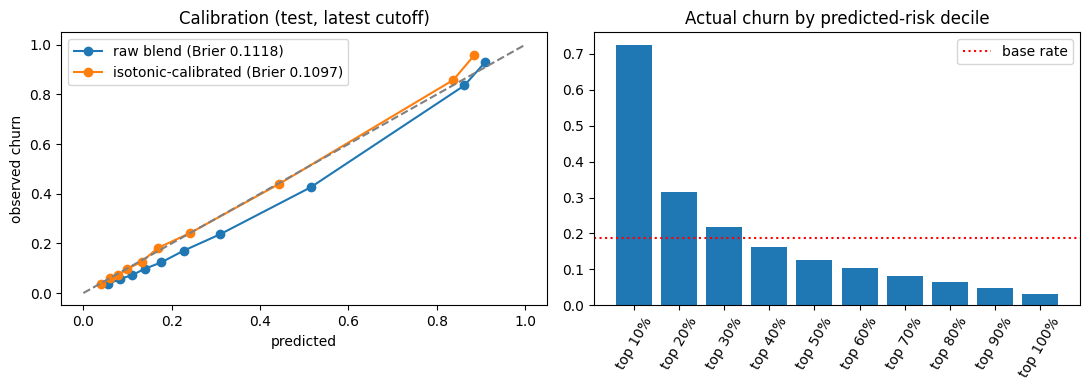

,users,actual_churn,avg_pred,cum_capture
top 10%,8132,0.723,0.723,0.385
top 20%,8132,0.314,0.316,0.552
top 30%,8132,0.218,0.213,0.668
top 40%,8132,0.162,0.160,0.755
top 50%,8131,0.127,0.131,0.822
top 60%,8132,0.105,0.105,0.878
top 70%,8132,0.081,0.088,0.921
top 80%,8132,0.066,0.068,0.957
top 90%,8132,0.049,0.054,0.983
top 100%,8132,0.032,0.035,1.000


In [17]:
from sklearn.calibration import calibration_curve
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for k, lab in [('blend', 'raw blend'), ('blend_cal', 'isotonic-calibrated')]:
    pt, pp = calibration_curve(y_l, np.clip(P_test_last[k], 0, 1), n_bins=10, strategy='quantile')
    ax[0].plot(pp, pt, marker='o', label=f'{lab} (Brier {brier_score_loss(y_l, np.clip(P_test_last[k], 0, 1)):.4f})')
ax[0].plot([0, 1], [0, 1], '--', color='gray'); ax[0].set_xlabel('predicted'); ax[0].set_ylabel('observed churn')
ax[0].set_title('Calibration (test, latest cutoff)'); ax[0].legend()

dec = pd.DataFrame({'p': P_test_last['blend_cal'][el], 'y': yb})
dec['decile'] = pd.qcut(dec['p'].rank(method='first'), 10, labels=False)
lift = dec.groupby('decile').agg(users=('y', 'size'), actual_churn=('y', 'mean'), avg_pred=('p', 'mean')).iloc[::-1]
lift['cum_capture'] = (lift['users'] * lift['actual_churn']).cumsum() / (lift['users'] * lift['actual_churn']).sum()
lift.index = [f'top {10*(i+1)}%' for i in range(len(lift))]
ax[1].bar(lift.index, lift['actual_churn']); ax[1].axhline(yb.mean(), color='red', ls=':', label='base rate')
ax[1].set_title('Actual churn by predicted-risk decile'); ax[1].tick_params(axis='x', rotation=60); ax[1].legend()
plt.tight_layout(); plt.show(); display(lift.round(3))

**Stability checks.** (1) 5-fold CV grouped by user on train+val: is performance stable across slices? (2) Purged time check: train only on early cutoffs whose label windows end on/before the latest cutoff, and score the latest cutoff. If (2) is far below the main result, the model is leaning on something time-specific.

In [18]:
from sklearn.model_selection import GroupKFold

CV_MAX_USERS = 100_000                              # lower this if memory is still tight
rs = np.random.RandomState(RANDOM_STATE)
tv_users = tv['user_id'].unique()
if len(tv_users) > CV_MAX_USERS:
    tv_users = rs.choice(tv_users, CV_MAX_USERS, replace=False)
tv_s = tv[tv['user_id'].isin(tv_users)].reset_index(drop=True)

def fit_plain(X, y):
    p = {**study_lgb.best_params, 'n_estimators': BEST_LGB_ITERS, 'subsample_freq': 1,
         'random_state': RANDOM_STATE, 'verbose': -1, 'n_jobs': -1}
    return lgb.LGBMClassifier(**p).fit(X, y)

X_tv, y_tv = to_frame(tv_s), tv_s['churn'].values
el_tv, g_tv = tv_s['eligible'].values == 1, tv_s['user_id'].values

cv = []
for f, (a, b) in enumerate(GroupKFold(n_splits=5).split(X_tv, groups=g_tv)):
    m = fit_plain(X_tv.iloc[a], y_tv[a])
    b = b[el_tv[b]]
    cv.append(average_precision_score(y_tv[b], m.predict_proba(X_tv.iloc[b])[:, 1]))
    print(f'  fold {f}: PR-AUC (eligible) = {cv[-1]:.4f}')
    del m; gc.collect()
CV_MEAN, CV_STD = float(np.mean(cv)), float(np.std(cv))
print(f'CV PR-AUC mean {CV_MEAN:.4f}  std {CV_STD:.4f}  (on {len(tv_users):,} users)')
del X_tv; gc.collect()

# purged time check: train only on early cutoffs, score the latest cutoff
early = train[(train.cutoff <= LAST - pd.Timedelta(days=HORIZON)) & (train['user_id'].isin(tv_users))]
if early.cutoff.nunique() >= 2:
    va_last = val[(val.cutoff == LAST) & (val.eligible == 1)]
    m_t = fit_plain(to_frame(early), early['churn'].values)
    ap_time = average_precision_score(va_last['churn'], m_t.predict_proba(to_frame(va_last))[:, 1])
    ap_main = average_precision_score(va_last['churn'], m_lgb.predict_proba(to_frame(va_last))[:, 1])
    print(f'latest cutoff, val users: ALL cutoffs {ap_main:.4f} vs PURGED early only {ap_time:.4f} (gap {ap_main - ap_time:+.4f})')
else:
    ap_time = np.nan; print('not enough early cutoffs for a purged time check')

  fold 0: PR-AUC (eligible) = 0.5796
  fold 1: PR-AUC (eligible) = 0.5757
  fold 2: PR-AUC (eligible) = 0.5708
  fold 3: PR-AUC (eligible) = 0.5734
  fold 4: PR-AUC (eligible) = 0.5811
CV PR-AUC mean 0.5761  std 0.0038  (on 100,000 users)
not enough early cutoffs for a purged time check


**Feature-group ablation** — what each family of features actually buys (cumulative, same fixed LightGBM, validation PR-AUC on eligible users). This is the evidence for the feature engineering, and the sanity check for leakage.

In [19]:
def quick_score(features, tr=None, va=None):
    tr = train if tr is None else tr; va = val if va is None else va
    cats = [c for c in CAT if c in features]
    A = cf.to_model_frame(tr, features, cats, CATEGORIES); B = cf.to_model_frame(va, features, cats, CATEGORIES)
    m = lgb.LGBMClassifier(n_estimators=min(MAX_TREES, 600), learning_rate=0.05, num_leaves=31, subsample=0.8,
                           subsample_freq=1, colsample_bytree=0.8, metric='average_precision',
                           random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)
    m.fit(A, tr['churn'].values, eval_set=[(B, va['churn'].values)],
          callbacks=[lgb.early_stopping(50, first_metric_only=True, verbose=False)])
    p = m.predict_proba(B)[:, 1]; el_ = va['eligible'].values == 1
    r = evaluate(va['churn'].values[el_], p[el_])
    return r['pr_auc'], r['lift@10%']

order = ['user_static', 'recency', 'windowed_activity', 'rhythm_gaps', 'momentum', 'history_baseline', 'mix_quality']
used, rows = [], []
for g in order:
    used += [c for c in cf.FEATURE_GROUPS[g] if c in FEATURES]
    pr, lf = quick_score(list(dict.fromkeys(used)))
    rows.append({'added group': g, 'n_features': len(set(used)), 'val_pr_auc': pr, 'lift@10%': lf})
ablation = pd.DataFrame(rows); ablation['gain'] = ablation['val_pr_auc'].diff()
display(ablation.round(4))

RUN_ENGAGEMENT_ABLATION = False    # True = test the 4 pre-aggregated engagement columns
if RUN_ENGAGEMENT_ABLATION:
    alt = cf.build_training_table(txns, users, CUTOFFS, HORIZON, use_engagement=True)
    with_eng = cf.feature_columns(alt)                      # take the feature list BEFORE adding 'split'
    alt['split'] = alt['user_id'].map(split_of)
    tr2, va2 = alt[alt.split == 'train'], alt[alt.split == 'val']
    without = [c for c in with_eng if c not in cf.ENGAGEMENT]
    a0, a1 = quick_score(without, tr2, va2)[0], quick_score(with_eng, tr2, va2)[0]
    print(f'val PR-AUC without engagement cols {a0:.4f} | with {a1:.4f} | delta {a1 - a0:+.4f}')
    print('A big positive delta is a LEAK WARNING (those columns are snapshot-dated May 19), not a win.')

,added group,n_features,val_pr_auc,lift@10%,gain
0,user_static,8,0.2735,1.5375,NaN
1,recency,11,0.4899,2.9951,0.2164
2,windowed_activity,26,0.5133,3.0376,0.0235
3,rhythm_gaps,31,0.5133,3.0407,-0.0000
4,momentum,36,0.5357,3.1687,0.0224
5,history_baseline,40,0.5752,3.3797,0.0395
6,mix_quality,51,0.5750,3.3798,-0.0002


## Stage 10 — Threshold: from first principles, chosen on validation

With **calibrated** probabilities the expected value of contacting a user with churn probability *p* is

`EV(p) = p × (SAVE_RATE × CUSTOMER_VALUE) − CAMPAIGN_COST`

which is positive when `p > CAMPAIGN_COST / (SAVE_RATE × CUSTOMER_VALUE)`. That closed-form threshold is compared with the one found empirically on **validation** (never on test). Only **eligible** users are contacted.

threshold chosen on validation = 0.30 | closed-form optimum = 0.30


,strategy,net_value_test_INR,scaled_to_full_base_INR
0,target no one,0.0,0.0
1,target every eligible user,-4560350.0,-22801797.0
2,model @ 0.30 (val-chosen),1803800.0,9019018.0
3,model @ 0.30 (closed-form),1803800.0,9019018.0


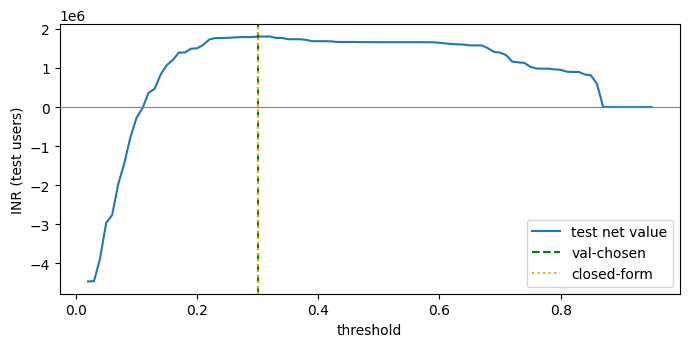

flagged 13,018 of 81,319 eligible users | precision 57.7% | recall 49.2%
 top_%  users  precision  recall
     1    813      0.852   0.045
     5   4065      0.839   0.223
    10   8131      0.723   0.385
    20  16263      0.519   0.552
    30  24395      0.418   0.668


In [20]:
Pval_all = predict_all(val)
pv, yv, elv = Pval_all['blend_cal'], val['churn'].values, val['eligible'].values == 1

def net_value(y, p, thr):
    flag = p >= thr
    tp, fp = (flag & (y == 1)).sum(), (flag & (y == 0)).sum()
    return tp * (CAMPAIGN_SAVE_RATE * AVG_CUSTOMER_VALUE - CAMPAIGN_COST) - fp * CAMPAIGN_COST

grid_t = np.linspace(0.02, 0.95, 94)
DEPLOY_THRESHOLD = float(grid_t[int(np.argmax([net_value(yv[elv], pv[elv], t) for t in grid_t]))])
THEORY_THRESHOLD = CAMPAIGN_COST / (CAMPAIGN_SAVE_RATE * AVG_CUSTOMER_VALUE)
print(f'threshold chosen on validation = {DEPLOY_THRESHOLD:.2f} | closed-form optimum = {THEORY_THRESHOLD:.2f}')

pt = P_test_last['blend_cal'][el]
test_user_frac = test_last['user_id'].nunique() / N_ALL_USERS
tv_ = lambda thr: net_value(yb, pt, thr)
all_ = yb.sum() * (CAMPAIGN_SAVE_RATE * AVG_CUSTOMER_VALUE - CAMPAIGN_COST) - (yb == 0).sum() * CAMPAIGN_COST
res = pd.DataFrame({'strategy': ['target no one', 'target every eligible user',
                                 f'model @ {DEPLOY_THRESHOLD:.2f} (val-chosen)', f'model @ {THEORY_THRESHOLD:.2f} (closed-form)'],
                    'net_value_test_INR': [0, all_, tv_(DEPLOY_THRESHOLD), tv_(THEORY_THRESHOLD)]})
res['scaled_to_full_base_INR'] = res['net_value_test_INR'] / test_user_frac
display(res.round(0))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(grid_t, [tv_(t) for t in grid_t], label='test net value')
ax.axvline(DEPLOY_THRESHOLD, color='green', ls='--', label='val-chosen'); ax.axvline(THEORY_THRESHOLD, color='orange', ls=':', label='closed-form')
ax.axhline(0, color='gray', lw=.8); ax.set_xlabel('threshold'); ax.set_ylabel('INR (test users)'); ax.legend(); plt.show()

flag = (pt >= DEPLOY_THRESHOLD).astype(int)
tp, fp, fn = ((flag == 1) & (yb == 1)).sum(), ((flag == 1) & (yb == 0)).sum(), ((flag == 0) & (yb == 1)).sum()
print(f'flagged {flag.sum():,} of {len(yb):,} eligible users | precision {tp/max(tp+fp,1):.1%} | recall {tp/max(tp+fn,1):.1%}')

# capacity view: the team can only call the top K%
o = np.argsort(-pt)
print(pd.DataFrame([{'top_%': f, 'users': int(len(o)*f/100), 'precision': yb[o[:max(1,int(len(o)*f/100))]].mean(),
                     'recall': yb[o[:max(1,int(len(o)*f/100))]].sum()/yb.sum()} for f in (1, 5, 10, 20, 30)]).round(3).to_string(index=False))

## Stage 11 — Explainability (why is this user at risk?)

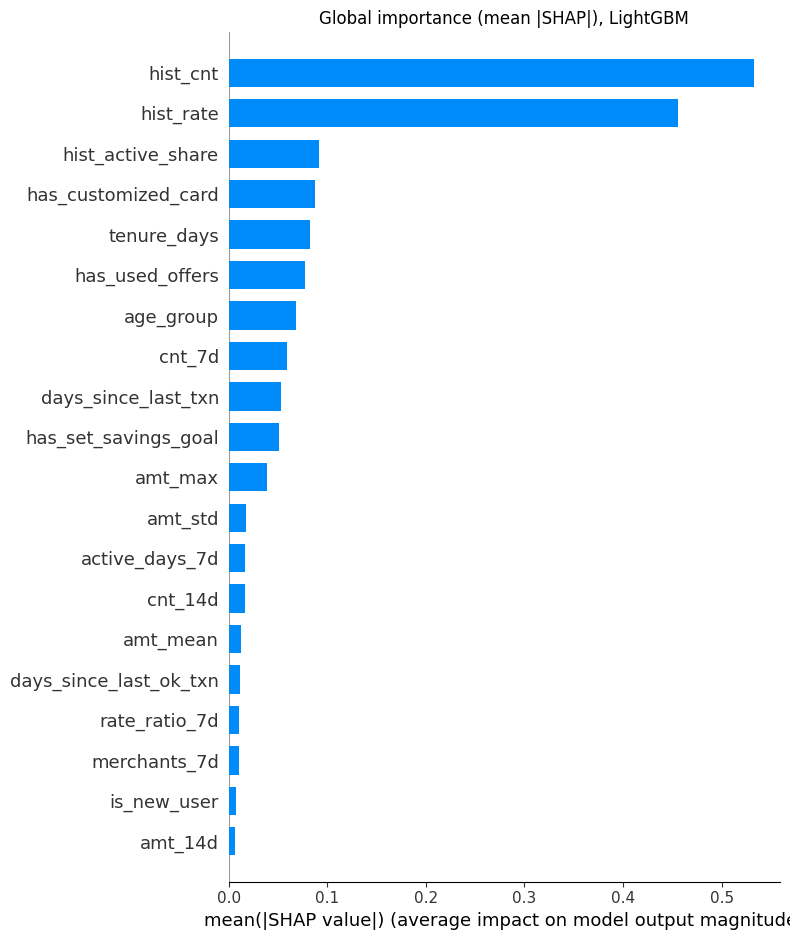

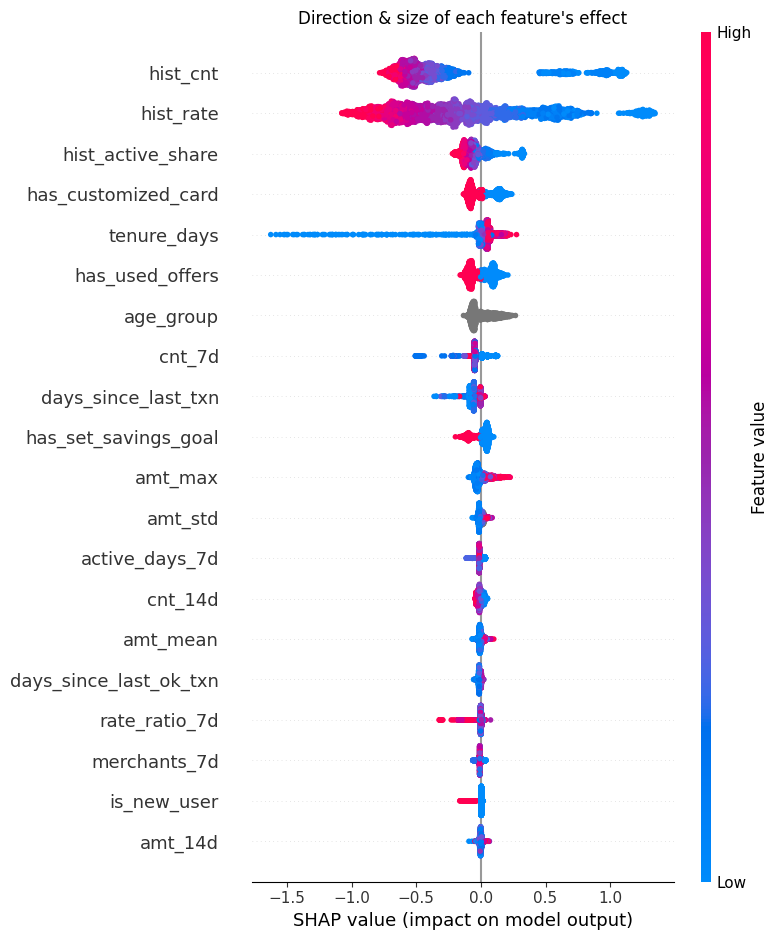

,user_id,risk,actual_churn,top_reasons
0,U000008,0.114,1,"age_group, has_used_offers, amt_max"
1,U000026,0.298,0,"hist_cnt, hist_rate, has_used_offers"
2,U000028,0.073,1,"has_customized_card, has_set_savings_goal, ten..."
3,U000032,0.387,1,"hist_rate, tenure_days, hist_active_share"
4,U000033,0.015,0,"tenure_days, has_set_savings_goal, cnt_7d_vs_p..."
5,U000042,0.010,0,"tenure_days, amt_14d, n_txn_types"
6,U000055,0.031,0,"has_set_savings_goal, active_span_days, city"
7,U000056,0.677,0,"hist_cnt, hist_rate, tenure_days"


In [21]:
try:
    import shap
    samp = test_last[test_last.eligible == 1].sample(min(3000, int(test_last.eligible.sum())), random_state=RANDOM_STATE)
    Xs = to_frame(samp)
    sv = shap.TreeExplainer(m_lgb).shap_values(Xs)
    if isinstance(sv, list): sv = sv[1]
    shap.summary_plot(sv, Xs, plot_type='bar', show=False, max_display=20); plt.title('Global importance (mean |SHAP|), LightGBM'); plt.tight_layout(); plt.show()
    shap.summary_plot(sv, Xs, show=False, max_display=20); plt.title('Direction & size of each feature\'s effect'); plt.tight_layout(); plt.show()
except ImportError:
    print('shap not installed - skipping plots; per-user reasons below do not need it')

# per-user reason codes straight from LightGBM (no shap dependency) - this is what ships in scoring
def reason_codes(d, top_k=3):
    X = to_frame(d); contrib = m_lgb.predict(X, pred_contrib=True)[:, :-1]
    top = np.argsort(-contrib, axis=1)[:, :top_k]
    return [', '.join(FEATURES[j] for j in row) for row in top]
_s = test_last[test_last.eligible == 1].head(8)
display(pd.DataFrame({'user_id': _s['user_id'].values, 'risk': P_test_last['blend_cal'][el][:8].round(3),
                      'actual_churn': _s['churn'].values, 'top_reasons': reason_codes(_s)}))

## Stage 12 — Segment analysis (test users, latest cutoff, eligible)

In [22]:
seg_src = test_last[test_last.eligible == 1].assign(risk=P_test_last['blend_cal'][el],
                                                     flagged=(P_test_last['blend_cal'][el] >= DEPLOY_THRESHOLD).astype(int))
for col in ['age_group', 'city', 'device_type']:
    s = seg_src.groupby(col).agg(users=('user_id', 'count'), actual_churn=('churn', 'mean'),
                                 avg_predicted=('risk', 'mean'), flagged_share=('flagged', 'mean'))
    print(f'--- by {col} ---'); display(s.sort_values('actual_churn', ascending=False).round(3))
# calibration gaps per segment (avg_predicted vs actual_churn) are the fairness/drift check to watch in monitoring

--- by age_group ---


,users,actual_churn,avg_predicted,flagged_share
age_group,,,,
31+,3868,0.253,0.255,0.192
23-30,11464,0.248,0.247,0.199
19-22,15990,0.203,0.209,0.169
11-15,20897,0.168,0.166,0.150
16-18,29100,0.162,0.164,0.143


--- by city ---


,users,actual_churn,avg_predicted,flagged_share
city,,,,
Pune,6579,0.194,0.194,0.167
Hyderabad,8205,0.190,0.187,0.158
Other,8163,0.190,0.191,0.160
Bangalore,16237,0.189,0.191,0.163
Chennai,8031,0.189,0.191,0.160
Ahmedabad,4003,0.186,0.187,0.156
Mumbai,12286,0.185,0.188,0.157
Kolkata,5653,0.185,0.185,0.157
Delhi,12162,0.184,0.189,0.159


--- by device_type ---


,users,actual_churn,avg_predicted,flagged_share
device_type,,,,
Android,61137,0.189,0.190,0.16
iOS,20182,0.185,0.188,0.16


## Stage 13 — Deployment package: bundle, scoring module, model card, monitoring

Artifacts in `churn_artifacts/`:
1. `churn_features.py` — shared feature logic (already written above)
2. `churn_bundle.joblib` — the three models, blend weights, calibrator, category lists, threshold, feature list
3. `churn_scoring.py` — `score_users(users, txns, cutoff)`; returns probability, flag and top reasons
4. `model_card.json`

In [23]:
import joblib
bundle = {'lgb': m_lgb, 'xgb': m_xgb, 'cb': m_cb, 'weights': W, 'calibrator': iso,
          'features': FEATURES, 'cat_features': CAT, 'categories': CATEGORIES,
          'threshold': DEPLOY_THRESHOLD, 'use_engagement': USE_ENGAGEMENT_COLS,
          'data_start': str(txns['transaction_date'].min()), 'horizon': HORIZON}
joblib.dump(bundle, f'{ARTIFACT_DIR}/churn_bundle.joblib')

model_card = {
    'model_id': 'fam_churn_v3', 'trained_on': pd.Timestamp.now().strftime('%Y-%m-%d'),
    'target': f'churn=1 if zero transactions in the {HORIZON} days after the cutoff',
    'population_scored': f'users with >=1 transaction in the previous {cf.LOOKBACK} days ("eligible")',
    'training_design': {'n_snapshots': len(CUTOFFS), 'first_cutoff': str(CUTOFFS[0].date()), 'last_cutoff': str(LAST.date()),
                        'lookback_days': cf.LOOKBACK, 'horizon_days': HORIZON, 'split': 'user-disjoint 60/20/20; test = held-out users at latest cutoff'},
    'n_features': len(FEATURES), 'features': FEATURES, 'categorical': CAT,
    'excluded_columns': ['is_active', 'days_since_last_transaction', 'days_since_registration (raw)'] +
                        ([] if USE_ENGAGEMENT_COLS else cf.ENGAGEMENT),
    'models': {'lightgbm': 'Optuna-tuned', 'xgboost': 'Optuna-tuned', 'catboost': 'fixed params', 'blend_weights': W,
               'calibration': 'isotonic on validation', 'n_trials': N_TRIALS},
    'metrics_test_latest_cutoff_eligible': {'pr_auc': float(HEADLINE.pr_auc), 'pr_auc_95ci': [float(ci[0]), float(ci[1])],
                                            'roc_auc': float(HEADLINE.roc_auc), 'lift_at_10pct': float(HEADLINE['lift@10%']),
                                            'base_rate': float(HEADLINE.base_rate)},
    'cv_pr_auc_mean': CV_MEAN, 'cv_pr_auc_std': CV_STD,
    'purged_time_check_pr_auc': None if np.isnan(ap_time) else float(ap_time),
    'deployment_threshold': DEPLOY_THRESHOLD, 'closed_form_threshold': THEORY_THRESHOLD,
    'business_assumptions': {'avg_customer_value_inr': AVG_CUSTOMER_VALUE, 'campaign_cost_inr': CAMPAIGN_COST,
                             'campaign_save_rate': CAMPAIGN_SAVE_RATE, 'note': 'PLACEHOLDERS - replace before use'},
    'known_limitations': [
        'About one month of data: snapshots overlap heavily, so effective sample size is far below row count; no seasonality seen.',
        'hist_* features are measured from data start; as history grows their meaning shifts - retrain or cap history at a fixed window.',
        'Retention-campaign save rate is an assumption; measure it with a randomised holdout and consider an uplift model.',
        'Engagement columns excluded (unknown computation window).',
        'Models deployed as trained on the train split (no refit) so calibration/threshold match exactly.'],
    'retrain_trigger': 'monthly, or when any feature PSI > 0.25, or when live precision@K drifts > 20% from test'}
json.dump(model_card, open(f'{ARTIFACT_DIR}/model_card.json', 'w'), indent=2)
print('saved bundle + model card ->', os.path.abspath(ARTIFACT_DIR))

saved bundle + model card -> c:\Users\Abhishek\Documents\projects\churn_prediction\User_Churn_Analysis_FamApp\notebooks\churn_artifacts


In [24]:
%%writefile churn_artifacts/churn_scoring.py
"""
churn_scoring.py -- batch scoring. Uses the SAME churn_features module as training.
Usage:  from churn_scoring import score_users
        scores = score_users(users_df, txns_df, cutoff='2025-06-01')   # txns up to cutoff (later rows are ignored)
"""
import os
import joblib
import numpy as np
import pandas as pd
import churn_features as cf

_HERE = os.path.dirname(os.path.abspath(__file__))


def load_bundle(path=None):
    return joblib.load(path or os.path.join(_HERE, 'churn_bundle.joblib'))


def score_users(users, txns, cutoff, bundle=None, explain=True, top_k=3):
    b = bundle or load_bundle()
    table = cf.build_live_table(txns, users, cutoff, b['data_start'], b['use_engagement'])
    X_tree = cf.to_model_frame(table, b['features'], b['cat_features'], b['categories'])
    X_cb = cf.to_model_frame(table, b['features'], b['cat_features'], b['categories'], as_string=True)
    w = b['weights']
    raw = (w['lgb'] * b['lgb'].predict_proba(X_tree)[:, 1]
           + w['xgb'] * b['xgb'].predict_proba(X_tree)[:, 1]
           + w['cb'] * b['cb'].predict_proba(X_cb)[:, 1])
    p = b['calibrator'].predict(raw)
    out = pd.DataFrame({'user_id': table['user_id'].values, 'eligible': table['eligible'].values,
                        'churn_probability': p, 'rank_score': raw})   # probability for EV math, raw blend for ranking
    out['churn_flag'] = ((p >= b['threshold']) & (table['eligible'].values == 1)).astype(int)
    if explain:
        contrib = b['lgb'].predict(X_tree, pred_contrib=True)[:, :-1]
        top = np.argsort(-contrib, axis=1)[:, :top_k]
        out['top_reasons'] = [', '.join(b['features'][j] for j in row) for row in top]
    return out.sort_values('rank_score', ascending=False).reset_index(drop=True)

Writing churn_artifacts/churn_scoring.py


In [25]:
# Smoke test + PARITY test: the deployed scoring path must reproduce the notebook's predictions exactly
import churn_scoring; importlib.reload(churn_scoring)
_users_sub = users[users['user_id'].isin(test_last['user_id'])]
sc = churn_scoring.score_users(_users_sub, txns, LAST)
ref = pd.DataFrame({'user_id': test_last['user_id'].values, 'p_ref': P_test_last['blend_cal']})
chk = sc.merge(ref, on='user_id')
assert len(chk) == len(ref) and np.abs(chk['churn_probability'] - chk['p_ref']).mean() < 1e-3
print('PASS: scoring module reproduces notebook predictions for', len(chk), 'users')
display(sc.head(10))

PASS: scoring module reproduces notebook predictions for 97838 users


,user_id,eligible,churn_probability,rank_score,churn_flag,top_reasons
0,U432822,0,1.0,0.944846,0,"hist_rate, hist_cnt, hist_active_share"
1,U009931,0,1.0,0.943905,0,"hist_rate, hist_cnt, hist_active_share"
2,U278731,0,1.0,0.943696,0,"hist_rate, hist_cnt, hist_active_share"
3,U372340,0,1.0,0.943514,0,"hist_rate, hist_cnt, hist_active_share"
4,U254915,0,1.0,0.943176,0,"hist_rate, hist_cnt, hist_active_share"
5,U179159,0,1.0,0.943166,0,"hist_rate, hist_cnt, hist_active_share"
6,U202117,0,1.0,0.943146,0,"hist_rate, hist_cnt, hist_active_share"
7,U374306,0,1.0,0.943119,0,"hist_rate, hist_cnt, hist_active_share"
8,U313420,0,1.0,0.943068,0,"hist_rate, hist_cnt, hist_active_share"
9,U148892,0,1.0,0.943068,0,"hist_rate, hist_cnt, hist_active_share"


In [26]:
# Monitoring: Population Stability Index per feature (run every scoring cycle)
def psi(expected, actual, bins=10):
    e, a = pd.Series(expected).dropna().values, pd.Series(actual).dropna().values
    if len(e) == 0 or len(a) == 0 or np.unique(e).size < 2: return np.nan
    br = np.unique(np.quantile(e, np.linspace(0, 1, bins + 1))); br[0], br[-1] = -np.inf, np.inf
    ep = np.histogram(e, br)[0] / len(e) + 1e-6; ap = np.histogram(a, br)[0] / len(a) + 1e-6
    return float(np.sum((ap - ep) * np.log(ap / ep)))

drift = pd.DataFrame({'feature': NUM, 'psi': [psi(train[c], test_last[c]) for c in NUM]}).sort_values('psi', ascending=False)
drift['status'] = pd.cut(drift['psi'], [-np.inf, 0.1, 0.25, np.inf], labels=['ok', 'investigate', 'retrain'])
print('PSI train vs latest cutoff (<0.1 ok, 0.1-0.25 investigate, >0.25 retrain):'); display(drift.head(10).round(4))
# also track in production: live precision@K once labels mature, calibration by segment, share of users flagged

PSI train vs latest cutoff (<0.1 ok, 0.1-0.25 investigate, >0.25 retrain):


,feature,psi,status
35,hist_active_days,0.1093,investigate
34,hist_cnt,0.0862,ok
38,hist_active_share,0.0733,ok
39,hist_rate,0.0680,ok
44,rate_ratio_7d,0.0343,ok
36,days_since_last_txn,0.0137,ok
37,days_since_last_ok_txn,0.0132,ok
10,cnt_7d,0.0053,ok
14,merchants_7d,0.0052,ok
13,active_days_7d,0.0048,ok


In [27]:
print('=' * 70); print('RESULTS SUMMARY'); print('=' * 70)
print(f'snapshots: {len(CUTOFFS)} | rows: {len(train) + len(val) + len(test_all):,} | features: {len(FEATURES)}')
print(f'HEADLINE (held-out users, latest cutoff, eligible): PR-AUC {HEADLINE.pr_auc:.4f} '
      f'(95% CI {ci[0]:.4f}-{ci[1]:.4f}) vs base rate {HEADLINE.base_rate:.3f}; ROC-AUC {HEADLINE.roc_auc:.4f}; lift@10% {HEADLINE["lift@10%"]:.2f}x')
print(f'recency-rule baseline PR-AUC {tbl_head[tbl_head.model=="rule_recency"].pr_auc.iloc[0]:.4f} | '
      f'logreg {tbl_head[tbl_head.model=="logreg"].pr_auc.iloc[0]:.4f}')
print(f'CV PR-AUC {CV_MEAN:.4f} +/- {CV_STD:.4f} | purged-time check {ap_time if not np.isnan(ap_time) else "n/a"}')
print(f'deploy threshold {DEPLOY_THRESHOLD:.2f} (closed-form {THEORY_THRESHOLD:.2f})')

RESULTS SUMMARY
snapshots: 4 | rows: 1,931,710 | features: 51
HEADLINE (held-out users, latest cutoff, eligible): PR-AUC 0.5772 (95% CI 0.5687-0.5861) vs base rate 0.188; ROC-AUC 0.8018; lift@10% 3.85x
recency-rule baseline PR-AUC 0.4077 | logreg 0.5519
CV PR-AUC 0.5761 +/- 0.0038 | purged-time check n/a
deploy threshold 0.30 (closed-form 0.30)


### Roadmap once more history arrives
1. **More months** → longer look-back (30/60/90d), seasonality and pay-day features, and a true forward-in-time validation (train Jan–Mar, test Apr).
2. **Timestamped engagement logs** → replace the four excluded pre-aggregated columns with windowed app-open / session features.
3. **Randomised retention holdout** → measure the real save rate and train an **uplift model** (who is *persuadable*), not just a churn model.
4. **Scheduled retraining + PSI alerts + live precision@K tracking** using `model_card.json` as the contract.